# Pesquisa em IA e adoção corporativa

**Projeto Aplicado — Análise e Visualização de Dados em Python**  
**Integrantes:** _preencher nomes_  
**Fonte principal:** Stanford HAI, *AI Index Report 2026*.

Este notebook relaciona a evolução da produção mundial de publicações de IA em Ciência da Computação com o uso de IA reportado por organizações. O recorte combina dados dos capítulos **1. Research and Development** e **4. Economy** e trata a relação como **associação exploratória**, não como evidência causal.


Nos oito anos coincidentes entre as séries (2017–2024), as publicações mundiais de IA em Ciência da Computação passaram de **116,9 mil** para **257,9 mil** (**+120,5%**) e a parcela de organizações que reportou usar IA em ao menos uma função passou de **20%** para **78%** (**+58 pontos percentuais**).

A correlação de Pearson entre os níveis anuais foi positiva e alta (**0,81**). Esse resultado mostra que anos com maior volume de publicações também tenderam a apresentar maior adoção reportada. Entretanto, a análise é exploratória: as duas séries crescem ao longo do tempo e o resultado não demonstra que o aumento da pesquisa tenha causado a adoção corporativa.

O resultado deve ser lido com cautela: são apenas oito observações anuais, as fontes e populações são diferentes, e a série de adoção provém de pesquisas anuais autorrelatadas.

## 1. Contexto e métodos

### 1.1 Problema e pergunta analítica

O *AI Index Report 2026*, produzido pelo Stanford Institute for Human-Centered Artificial Intelligence (HAI), reúne indicadores sobre pesquisa, economia e outros domínios da inteligência artificial. O problema investigado é a possível associação temporal entre a expansão da pesquisa em IA e sua difusão no ambiente corporativo.

**Pergunta central:** como evoluíram as publicações mundiais de IA em Ciência da Computação e a proporção de organizações que usam IA, e que associação exploratória aparece nos anos coincidentes de 2017 a 2024?

**Hipótese exploratória:** as duas séries podem crescer conjuntamente conforme a IA se desenvolve e se difunde. Para avaliar essa relação, utilizamos um gráfico de dispersão e a correlação de Pearson entre os níveis anuais. O resultado é interpretado como associação descritiva, não como evidência de causalidade.

### 1.2 Pressupostos-chave

- A unidade de análise da correlação é o **ano**, não a empresa, o artigo ou o país.
- Publicações são medidas em milhares; adoção é a proporção de respondentes cuja organização usa IA em ao menos uma função.
- Os dados são agregados globais de fontes independentes e não constituem observações pareadas por empresa ou país.
- Correlação descreve associação; não identifica direção causal nem controla investimento, custo computacional, regulação ou outros fatores.

### 1.3 Origem e contexto dos dados

A série de publicações deriva do **OpenAlex** e considera publicações em inglês classificadas como relacionadas à IA pelo CSO Classifier. O próprio relatório ressalta que volume não mede qualidade e que nem toda pesquisa aparece em bases indexadas.

A série de adoção deriva das pesquisas anuais *State of AI*, da **McKinsey & Company**. Para 2025, a pesquisa online recebeu 1.993 respostas de 105 países, abrangendo regiões, setores, portes e funções; os resultados foram ponderados pela contribuição de cada país ao PIB global. O relatório classifica os resultados autorrelatados como direcionais, não abrangentes, e reúne as edições anteriores para formar a série histórica.

Para cumprir a etapa de codificação categórica, também usamos a composição das publicações de IA por **setor** e **área geográfica** em 2024.

**Arquivos escolhidos**

| Figura | Arquivo | Papel na análise |
|---|---|---|
| 1.6.1 | `1. Research and Development/Data/fig_1.6.1.csv` | Volume e participação das publicações de IA, 2013–2024 |
| 1.6.9 | `1. Research and Development/Data/fig_1.6.9.csv` | Composição setorial em EUA, Europa e China, 2024 |
| 4.3.1 | `4. Economy/Data/fig_4.3.1(1).csv` | Uso organizacional de IA, 2017–2025, e de IA generativa, 2023–2025 |


## 2. Dados

### 2.1 Bibliotecas e caminhos

O código usa `pandas`, `matplotlib` e `scikit-learn`, conforme o conteúdo da disciplina. Os caminhos são relativos à pasta do projeto e os arquivos originais não são alterados.

In [1]:
import sys

import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from sklearn.preprocessing import OneHotEncoder

pd.set_option("display.max_columns", 30)

PATH_PUBLICATIONS = "AI_INDEX_REPORT_2026/1. Research and Development/Data/fig_1.6.1.csv"
PATH_SECTORS = "AI_INDEX_REPORT_2026/1. Research and Development/Data/fig_1.6.9.csv"
PATH_ADOPTION = "AI_INDEX_REPORT_2026/4. Economy/Data/fig_4.3.1(1).csv"

print("Caminhos dos três arquivos de entrada definidos.")

Caminhos dos três arquivos de entrada definidos.


### 2.2 Leitura e caracterização estrutural

O carregamento abaixo registra dimensões, tipos e uma amostra limitada de cada arquivo. Os nomes originais das colunas são preservados nesta etapa para manter a rastreabilidade.


In [2]:
publications_raw = pd.read_csv(PATH_PUBLICATIONS)
sectors_raw = pd.read_csv(PATH_SECTORS)
adoption_raw = pd.read_csv(PATH_ADOPTION)

print("PUBLICAÇÕES")
publications_raw.info()
display(publications_raw.head())

print("\nSETORES")
sectors_raw.info()
display(sectors_raw.head())

print("\nADOÇÃO")
adoption_raw.info()
display(adoption_raw.head())

PUBLICAÇÕES
<class 'pandas.DataFrame'>
RangeIndex: 24 entries, 0 to 23
Data columns (total 2 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   Year                                            24 non-null     int64  
 1   Number of AI publications in CS (in thousands)  24 non-null     float64
dtypes: float64(1), int64(1)
memory usage: 516.0 bytes


,Year,Number of AI publications in CS (in thousands)
0,2013,101.885
1,2014,104.409
2,2015,105.741
3,2016,107.269
4,2017,116.937



SETORES
<class 'pandas.DataFrame'>
RangeIndex: 12 entries, 0 to 11
Data columns (total 3 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   AI Publications (% of Total)  12 non-null     float64
 1   Sector                        12 non-null     str    
 2   Label                         12 non-null     str    
dtypes: float64(1), str(2)
memory usage: 420.0 bytes


,AI Publications (% of Total),Sector,Label
0,0.508483,Academia,United States
1,0.244636,Industry,United States
2,0.131113,Nonprofit,United States
3,0.115768,Government,United States
4,0.552982,Academia,Europe



ADOÇÃO
<class 'pandas.DataFrame'>
RangeIndex: 12 entries, 0 to 11
Data columns (total 3 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Year              12 non-null     int64  
 1   % of respondents  12 non-null     float64
 2   Label             12 non-null     str    
dtypes: float64(1), int64(1), str(1)
memory usage: 420.0 bytes


,Year,% of respondents,Label
0,2023,0.33,GenAI
1,2024,0.71,GenAI
2,2025,0.79,GenAI
3,2017,0.20,AI
4,2018,0.47,AI


**Dicionário dos atributos relevantes**

- `Year`: ano da observação.
- `Number of AI publications in CS (in thousands)`: o arquivo reúne, na mesma coluna, a contagem em milhares e a participação das publicações de IA no total de Ciência da Computação.
- `% of respondents`: proporção dos respondentes que reportaram uso organizacional de IA ou IA generativa.
- `Label` no arquivo de adoção: identifica as séries `AI` e `GenAI`.
- `AI Publications (% of Total)`: participação de cada setor no total regional de publicações de IA em 2024.
- `Sector` e `Label` no arquivo setorial: setor de origem e área geográfica, respectivamente.


## 3. Qualidade e preparação dos dados

### 3.1 Valores ausentes, duplicidades e cardinalidade

A auditoria distingue duplicatas exatas de repetições de uma chave parcial. Um ano repetido pode ser legítimo quando o arquivo contém mais de uma métrica ou série.


In [3]:
quality_publications = pd.DataFrame({
    "nulos": publications_raw.isna().sum(),
    "nulos_%": (publications_raw.isna().mean() * 100).round(2),
    "valores_distintos": publications_raw.nunique(),
})

quality_sectors = pd.DataFrame({
    "nulos": sectors_raw.isna().sum(),
    "nulos_%": (sectors_raw.isna().mean() * 100).round(2),
    "valores_distintos": sectors_raw.nunique(),
})

quality_adoption = pd.DataFrame({
    "nulos": adoption_raw.isna().sum(),
    "nulos_%": (adoption_raw.isna().mean() * 100).round(2),
    "valores_distintos": adoption_raw.nunique(),
})

print("Qualidade — publicações")
display(quality_publications)
print("Qualidade — setores")
display(quality_sectors)
print("Qualidade — adoção")
display(quality_adoption)

duplicates = pd.DataFrame({
    "conjunto": ["Publicações", "Setores", "Adoção"],
    "duplicatas_exatas": [
        publications_raw.duplicated().sum(),
        sectors_raw.duplicated().sum(),
        adoption_raw.duplicated().sum(),
    ],
    "duplicatas_exatas_%": [
        publications_raw.duplicated().mean() * 100,
        sectors_raw.duplicated().mean() * 100,
        adoption_raw.duplicated().mean() * 100,
    ],
})
display(duplicates.round(2))

print(
    "Chaves Year + Label repetidas na adoção:",
    adoption_raw.duplicated(subset=["Year", "Label"]).sum(),
)
print(
    "Chaves Sector + Label repetidas nos setores:",
    sectors_raw.duplicated(subset=["Sector", "Label"]).sum(),
)

Qualidade — publicações


,nulos,nulos_%,valores_distintos
Year,0,0.0,12
Number of AI publications in CS (in thousands),0,0.0,24


Qualidade — setores


,nulos,nulos_%,valores_distintos
AI Publications (% of Total),0,0.0,12
Sector,0,0.0,4
Label,0,0.0,3


Qualidade — adoção


,nulos,nulos_%,valores_distintos
Year,0,0.0,9
% of respondents,0,0.0,11
Label,0,0.0,2


,conjunto,duplicatas_exatas,duplicatas_exatas_%
0,Publicações,0,0.0
1,Setores,0,0.0
2,Adoção,0,0.0


Chaves Year + Label repetidas na adoção: 0
Chaves Sector + Label repetidas nos setores: 0


### 3.2 Transformação da série de publicações

A figura 1.6.1 possui uma ambiguidade estrutural: a mesma coluna numérica contém **contagens em milhares** e **proporções**, e cada ano aparece duas vezes. A figura original mostra explicitamente essas duas medidas em eixos separados.

A reconstrução separa valores maiores que 1 como contagens e valores entre 0 e 1 como proporções. Depois, as duas tabelas são unidas pelo ano, produzindo uma linha por período e uma coluna para cada métrica.


In [4]:
publication_value = "Number of AI publications in CS (in thousands)"

# O arquivo reúne contagens em milhares e proporções na mesma coluna.
# Valores maiores que 1 são as contagens; valores entre 0 e 1 são proporções.
publication_counts = publications_raw.loc[
    publications_raw[publication_value] > 1,
    ["Year", publication_value],
].copy()
publication_counts = publication_counts.rename(
    columns={publication_value: "publications_thousands"}
)

publication_shares = publications_raw.loc[
    publications_raw[publication_value] <= 1,
    ["Year", publication_value],
].copy()
publication_shares = publication_shares.rename(
    columns={publication_value: "publication_share"}
)

publication_series = pd.merge(
    publication_counts,
    publication_shares,
    on="Year",
    how="inner",
).sort_values("Year")

print("Série reconstruída com uma linha por ano:")
display(publication_series)

Série reconstruída com uma linha por ano:


,Year,publications_thousands,publication_share
0,2013,101.885,0.216348
1,2014,104.409,0.217533
2,2015,105.741,0.216678
3,2016,107.269,0.219654
4,2017,116.937,0.234228
5,2018,139.711,0.258366
6,2019,164.199,0.287115
7,2020,181.107,0.303066
8,2021,204.054,0.360123
9,2022,202.734,0.390286


### 3.3 Preparação da adoção e da composição setorial

As proporções são mantidas como frações entre 0 e 1 durante os cálculos e convertidas para percentual apenas na apresentação. `AI` é a série da correlação; `GenAI` permanece como contexto descritivo recente.


In [5]:
adoption_ai = adoption_raw.loc[
    adoption_raw["Label"] == "AI",
    ["Year", "% of respondents"],
].copy().sort_values("Year")

adoption_genai = adoption_raw.loc[
    adoption_raw["Label"] == "GenAI",
    ["Year", "% of respondents"],
].copy().sort_values("Year")

sectors = sectors_raw.rename(columns={
    "AI Publications (% of Total)": "publication_share",
    "Label": "Geographic area",
}).copy()

sector_reconciliation = sectors.groupby("Geographic area")["publication_share"].sum()

print(
    f"Adoção de IA: {len(adoption_ai)} anos "
    f"({adoption_ai['Year'].min()}–{adoption_ai['Year'].max()})"
)
print(
    f"Adoção de IA generativa: {len(adoption_genai)} anos "
    f"({adoption_genai['Year'].min()}–{adoption_genai['Year'].max()})"
)
print("Soma das participações setoriais por região:")
display((sector_reconciliation * 100).round(2).rename("soma_%").to_frame())

Adoção de IA: 9 anos (2017–2025)
Adoção de IA generativa: 3 anos (2023–2025)
Soma das participações setoriais por região:


,soma_%
Geographic area,
China,100.0
Europe,100.0
United States,100.0


### 3.4 Possíveis outliers

Aplicamos o critério do intervalo interquartil (IQR): valores abaixo de $Q1 - 1{,}5 \times IQR$ ou acima de $Q3 + 1{,}5 \times IQR$ são sinalizados para inspeção. Em séries temporais com tendência, extremos nas pontas podem ser observações reais; por isso o critério é diagnóstico, não uma regra automática de exclusão.

,série,n_sinalizados,anos_sinalizados
0,Publicações (milhares),0,nenhum
1,Uso organizacional de IA,3,"2017, 2024, 2025"


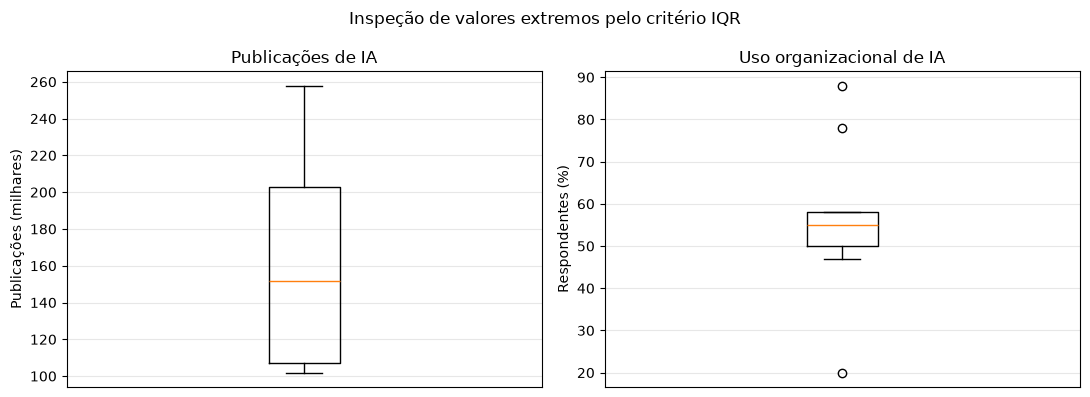

In [6]:
def buscar_outliers(serie_coluna):
    q1 = serie_coluna.quantile(0.25)
    q3 = serie_coluna.quantile(0.75)
    iqr = q3 - q1
    limite_inferior = q1 - 1.5 * iqr
    limite_superior = q3 + 1.5 * iqr
    return serie_coluna[
        (serie_coluna < limite_inferior)
        | (serie_coluna > limite_superior)
    ]


publication_outliers = buscar_outliers(
    publication_series["publications_thousands"]
)
adoption_outliers = buscar_outliers(adoption_ai["% of respondents"])

publication_outlier_years = publication_series.loc[
    publication_outliers.index, "Year"
].astype(str).tolist()
adoption_outlier_years = adoption_ai.loc[
    adoption_outliers.index, "Year"
].astype(str).tolist()

outlier_summary = pd.DataFrame({
    "série": ["Publicações (milhares)", "Uso organizacional de IA"],
    "n_sinalizados": [len(publication_outliers), len(adoption_outliers)],
    "anos_sinalizados": [
        ", ".join(publication_outlier_years) or "nenhum",
        ", ".join(adoption_outlier_years) or "nenhum",
    ],
})
display(outlier_summary)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].boxplot(publication_series["publications_thousands"])
axes[0].set_title("Publicações de IA")
axes[0].set_ylabel("Publicações (milhares)")
axes[0].set_xticks([])
axes[0].grid(axis="y", alpha=0.3)

axes[1].boxplot(adoption_ai["% of respondents"] * 100)
axes[1].set_title("Uso organizacional de IA")
axes[1].set_ylabel("Respondentes (%)")
axes[1].set_xticks([])
axes[1].grid(axis="y", alpha=0.3)

fig.suptitle("Inspeção de valores extremos pelo critério IQR")
plt.tight_layout()
plt.show()

**Decisões de tratamento.** Não há valores ausentes nem duplicatas exatas nos três arquivos selecionados. As repetições de ano são explicadas por métricas ou rótulos distintos. Os anos 2017, 2024 e 2025 são sinalizados na série de adoção pelo IQR, mas são plausíveis no contexto de uma tendência de difusão e não apresentam evidência de erro; por isso foram mantidos. Não foi realizada imputação nem remoção de registros.

Para uma aplicação futura, seria necessário confirmar alterações de questionário, composição da amostra e ponderação em cada edição da pesquisa. Esses aspectos podem introduzir quebras de comparabilidade mesmo quando o arquivo não possui nulos ou duplicatas.


## 4. Resultados

### 4.1 Estatísticas descritivas e alinhamento temporal

A comparação principal usa apenas os anos presentes nas duas séries. Isso evita preencher 2025 com uma publicação ainda não observada ou extrapolar valores.


In [7]:
aligned = pd.merge(
    publication_series[["Year", "publications_thousands"]],
    adoption_ai,
    on="Year",
    how="inner",
).sort_values("Year")

aligned["organizational_ai_use_pct"] = aligned["% of respondents"] * 100
aligned = aligned.drop(columns="% of respondents")

print(
    f"Anos coincidentes: {aligned['Year'].min()}–{aligned['Year'].max()} "
    f"| n = {len(aligned)}"
)
display(aligned)

print("Estatísticas descritivas do período coincidente:")
display(
    aligned[["publications_thousands", "organizational_ai_use_pct"]]
    .describe()
    .round(2)
)

Anos coincidentes: 2017–2024 | n = 8


,Year,publications_thousands,organizational_ai_use_pct
0,2017,116.937,20.0
1,2018,139.711,47.0
2,2019,164.199,58.0
3,2020,181.107,50.0
4,2021,204.054,56.0
5,2022,202.734,50.0
6,2023,242.664,55.0
7,2024,257.891,78.0


Estatísticas descritivas do período coincidente:


,publications_thousands,organizational_ai_use_pct
count,8.00,8.00
mean,188.66,51.75
std,48.31,16.01
min,116.94,20.00
25%,158.08,49.25
50%,191.92,52.50
75%,213.71,56.50
max,257.89,78.00


### 4.2 Evolução temporal

Os gráficos são separados porque os indicadores possuem unidades e janelas diferentes. A escala percentual permanece de 0% a 100%, evitando exagerar pequenas variações.


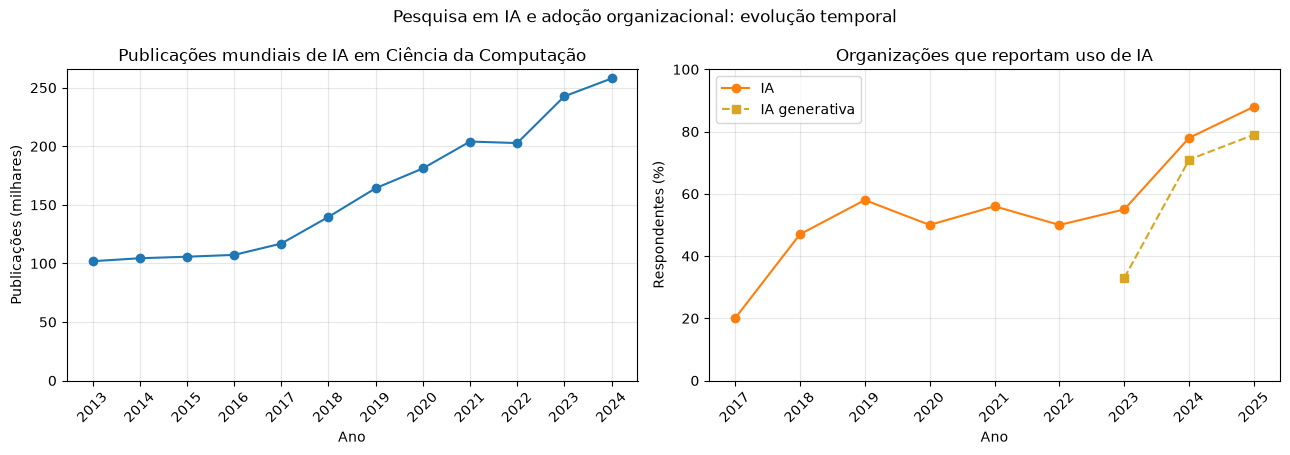

No intervalo coincidente, as publicações cresceram 120.5% e o uso organizacional aumentou 58.0 pontos percentuais.


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))

axes[0].plot(
    publication_series["Year"],
    publication_series["publications_thousands"],
    color="tab:blue",
    marker="o",
)
axes[0].set_title("Publicações mundiais de IA em Ciência da Computação")
axes[0].set_xlabel("Ano")
axes[0].set_ylabel("Publicações (milhares)")
axes[0].set_xticks(publication_series["Year"])
axes[0].tick_params(axis="x", rotation=45)
axes[0].set_ylim(bottom=0)
axes[0].grid(alpha=0.3)

axes[1].plot(
    adoption_ai["Year"],
    adoption_ai["% of respondents"] * 100,
    color="tab:orange",
    marker="o",
    label="IA",
)
axes[1].plot(
    adoption_genai["Year"],
    adoption_genai["% of respondents"] * 100,
    color="goldenrod",
    marker="s",
    linestyle="--",
    label="IA generativa",
)
axes[1].set_title("Organizações que reportam uso de IA")
axes[1].set_xlabel("Ano")
axes[1].set_ylabel("Respondentes (%)")
axes[1].set_xticks(sorted(adoption_raw["Year"].unique()))
axes[1].tick_params(axis="x", rotation=45)
axes[1].set_ylim(0, 100)
axes[1].legend()
axes[1].grid(alpha=0.3)

fig.suptitle("Pesquisa em IA e adoção organizacional: evolução temporal")
plt.tight_layout()
plt.show()

publication_growth_pct = (
    aligned["publications_thousands"].iloc[-1]
    / aligned["publications_thousands"].iloc[0]
    - 1
) * 100
adoption_change_pp = (
    aligned["organizational_ai_use_pct"].iloc[-1]
    - aligned["organizational_ai_use_pct"].iloc[0]
)

print(
    f"No intervalo coincidente, as publicações cresceram "
    f"{publication_growth_pct:.1f}% e o uso organizacional aumentou "
    f"{adoption_change_pp:.1f} pontos percentuais."
)

### 4.3 Associação entre pesquisa e adoção

O diagrama de dispersão relaciona os dois indicadores nos oito anos coincidentes. Cada ponto representa um ano. Em seguida, calculamos a correlação de Pearson para resumir a direção e a intensidade da associação linear.

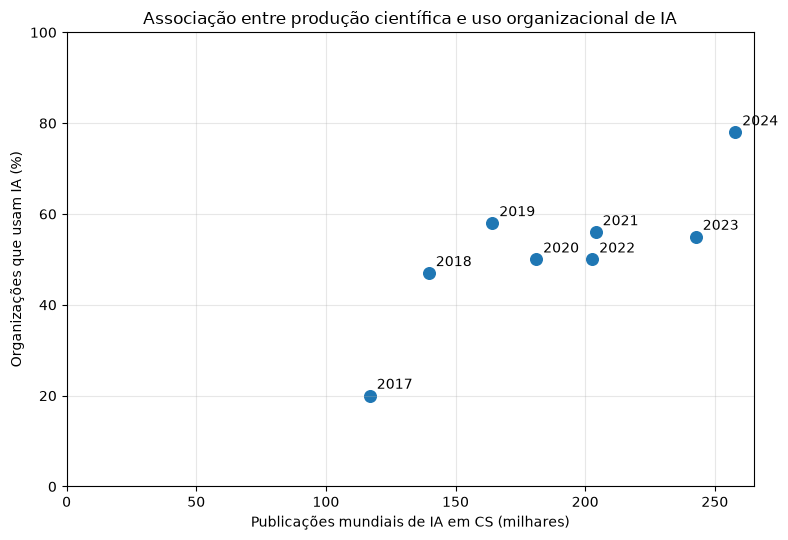

In [9]:
plt.figure(figsize=(8, 5.5))
plt.scatter(
    aligned["publications_thousands"],
    aligned["organizational_ai_use_pct"],
    color="tab:blue",
    s=70,
)

for _, row in aligned.iterrows():
    plt.annotate(
        str(int(row["Year"])),
        (row["publications_thousands"], row["organizational_ai_use_pct"]),
        xytext=(5, 5),
        textcoords="offset points",
    )

plt.title("Associação entre produção científica e uso organizacional de IA")
plt.xlabel("Publicações mundiais de IA em CS (milhares)")
plt.ylabel("Organizações que usam IA (%)")
plt.xlim(left=0)
plt.ylim(0, 100)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [10]:
pearson = aligned["publications_thousands"].corr(
    aligned["organizational_ai_use_pct"],
    method="pearson",
)

print(f"Correlação de Pearson = {pearson:.3f} (n={len(aligned)}).")

Correlação de Pearson = 0.813 (n=8).


**Interpretação.** A correlação de Pearson de 0,81 indica uma associação linear positiva entre os níveis anuais: anos com mais publicações tenderam a apresentar maior adoção organizacional. Como a amostra possui somente oito anos e as duas séries crescem ao longo do tempo, o resultado deve ser interpretado como associação descritiva e não como evidência de causalidade.

### 4.4 Quem produz a pesquisa? Composição por setor e região

A figura complementar contextualiza a pesquisa: a academia responde pela maior parcela nas três regiões, enquanto a participação relativa de indústria e governo varia. As participações somam 100% em cada região.

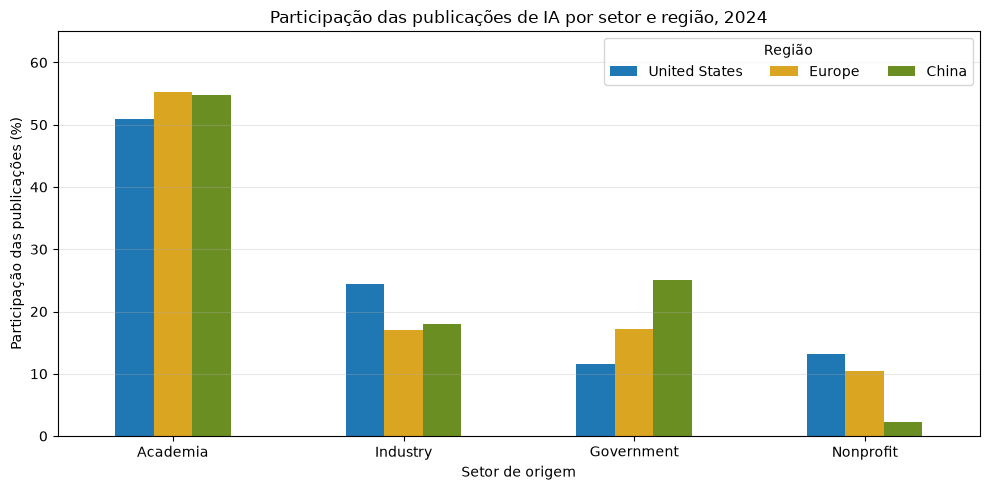

Geographic area,United States,Europe,China
Sector,,,
Academia,50.85,55.30,54.72
Industry,24.46,17.06,17.96
Government,11.58,17.27,25.10
Nonprofit,13.11,10.38,2.22


In [11]:
sector_order = ["Academia", "Industry", "Government", "Nonprofit"]
region_order = ["United States", "Europe", "China"]

sector_pivot = sectors.pivot(
    index="Sector",
    columns="Geographic area",
    values="publication_share",
)
sector_pivot = sector_pivot.reindex(
    index=sector_order,
    columns=region_order,
) * 100

ax = sector_pivot.plot(
    kind="bar",
    figsize=(10, 5),
    color=["tab:blue", "goldenrod", "olivedrab"],
)
ax.set_title("Participação das publicações de IA por setor e região, 2024")
ax.set_xlabel("Setor de origem")
ax.set_ylabel("Participação das publicações (%)")
ax.set_ylim(0, 65)
ax.legend(title="Região", ncol=3)
ax.tick_params(axis="x", rotation=0)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

display(sector_pivot.round(2))

## 5. Codificação dos atributos categóricos

`Sector` e `Geographic area` são variáveis **nominais**, pois suas categorias não possuem ordem natural. Por isso, usamos **One-Hot Encoding**, a mesma técnica aplicada nos exemplos da disciplina.

Cada categoria é transformada em uma coluna binária. Depois, removemos as colunas categóricas originais e juntamos as novas colunas numéricas ao conjunto de dados.

In [12]:
colunas_categoricas = ["Sector", "Geographic area"]
categorias = sectors[colunas_categoricas]

encoder = OneHotEncoder(sparse_output=False)
categorias_codificadas = encoder.fit_transform(categorias)
nomes_novas_colunas = encoder.get_feature_names_out(colunas_categoricas)

categorias_codificadas_df = pd.DataFrame(
    categorias_codificadas,
    columns=nomes_novas_colunas,
    index=sectors.index,
).astype(int)

setores_preparados = sectors.drop(columns=colunas_categoricas)
setores_preparados = pd.concat(
    [setores_preparados, categorias_codificadas_df],
    axis=1,
)

print("Antes da codificação:", sectors.shape)
display(sectors.head(6))

print("Depois da codificação:", setores_preparados.shape)
display(setores_preparados.head(6))

print("Novas colunas:")
print(nomes_novas_colunas)

Antes da codificação: (12, 3)


,publication_share,Sector,Geographic area
0,0.508483,Academia,United States
1,0.244636,Industry,United States
2,0.131113,Nonprofit,United States
3,0.115768,Government,United States
4,0.552982,Academia,Europe
5,0.172687,Government,Europe


Depois da codificação: (12, 8)


,publication_share,Sector_Academia,Sector_Government,Sector_Industry,Sector_Nonprofit,Geographic area_China,Geographic area_Europe,Geographic area_United States
0,0.508483,1,0,0,0,0,0,1
1,0.244636,0,0,1,0,0,0,1
2,0.131113,0,0,0,1,0,0,1
3,0.115768,0,1,0,0,0,0,1
4,0.552982,1,0,0,0,0,1,0
5,0.172687,0,1,0,0,0,1,0


Novas colunas:
['Sector_Academia' 'Sector_Government' 'Sector_Industry'
 'Sector_Nonprofit' 'Geographic area_China' 'Geographic area_Europe'
 'Geographic area_United States']


## 6. Conclusões e aplicações futuras

**Resposta à pergunta central.** Entre 2017 e 2024, o volume mundial de publicações de IA em Ciência da Computação e a adoção organizacional reportada cresceram de forma globalmente alinhada. A correlação de Pearson entre os níveis anuais foi positiva e alta (**0,81**). Assim, os dados mostram que anos com maior produção científica também tenderam a apresentar maior adoção, mas não demonstram que uma variável tenha causado a outra.

**Principais limitações**

- Apenas oito anos coincidentes.
- Indicadores agregados globais, sem pareamento entre pesquisa, países, setores e organizações.
- As duas séries crescem ao longo do tempo, o que pode aumentar a correlação observada.
- Publicações medem volume, não qualidade, impacto ou transferência tecnológica.
- Adoção é autorrelatada e pode ser afetada por composição amostral, ponderação e mudanças de questionário.
- Investimento, disponibilidade de modelos, custo computacional e regulação podem afetar ambas as séries.

**Possível aplicação futura de IA.** Com uma base em painel por país, setor e ano, seria possível estimar ou classificar níveis futuros de adoção a partir de pesquisa, patentes, investimento, capital humano e infraestrutura. `Sector` e `Geographic area` poderiam entrar por One-Hot Encoding. A validação deveria ser temporal, treinando em anos anteriores e testando em anos posteriores. A base atual é adequada para exploração e preparação, mas pequena e agregada demais para treinar um modelo confiável.

**Próximos passos.** Buscar microdados comparáveis; documentar mudanças metodológicas anuais; adicionar possíveis defasagens entre pesquisa e adoção; comparar países ou setores na mesma unidade; e testar a relação com séries mais longas e controles externos.

## 7. Referências e reprodutibilidade

- Stanford Institute for Human-Centered Artificial Intelligence. *The AI Index 2026 Annual Report*. DOI: https://doi.org/10.48550/arXiv.2606.15708.
- Figura 1.6.1: *AI publications in CS worldwide, 2013–24* (relatório, p. 47; arquivo local `fig_1.6.1.csv`).
- Figura 1.6.9: *AI publications in CS (% of total) by sector and geographic area, 2024* (relatório, p. 52; arquivo local `fig_1.6.9.csv`).
- Figura 4.3.1: *Share of respondents who say their organization uses AI in at least one function, 2017–25* (relatório, p. 193; arquivo local `fig_4.3.1(1).csv`).
- Metodologia da pesquisa McKinsey: apêndice do relatório, pp. 396–397.
- Dados públicos e gráficos do relatório: https://drive.google.com/drive/folders/1zJTOg0iR0j5SijCwFutwWvDt143lW277?usp=sharing.

Para reproduzir, mantenha este notebook na pasta que contém `AI_INDEX_REPORT_2026` e execute todas as células em ordem. Versões das bibliotecas usadas são exibidas abaixo.


In [13]:
import matplotlib
import sklearn

versions = pd.DataFrame({
    "biblioteca": ["Python", "pandas", "matplotlib", "scikit-learn"],
    "versão": [
        sys.version.split()[0],
        pd.__version__,
        matplotlib.__version__,
        sklearn.__version__,
    ],
})
display(versions)

,biblioteca,versão
0,Python,3.13.14
1,pandas,3.0.6
2,matplotlib,3.11.2
3,scikit-learn,1.9.1


### Declaração de uso de IA generativa

Foi utilizada uma ferramenta de IA generativa como apoio à seleção do recorte analítico, revisão e organização do código, sugestões de visualização, verificação de consistência e revisão textual. A interpretação final, a validação dos resultados e a responsabilidade pelo conteúdo entregue permanecem com o grupo. Todos os integrantes devem compreender e conseguir explicar o código, os métodos, as escolhas e as conclusões apresentadas.
